# Ph?n T?ch C?m X?c ?a Kh?a C?nh (ABSA) - RoBERTa-VN Novel
Fine-tune `NlpHUST/roberta-base-vn` v?i ki?n tr?c aspect-aware hierarchical t? x?y.

Notebook gi? c?ng skeleton gi?i th?ch v?i notebook BiGRU + Conv1D: d? li?u -> c?n b?ng d? li?u -> m? h?nh -> loss -> hu?n luy?n -> ??nh gi? -> confusion matrix -> demo inference.
Kh?c bi?t l? ch? ch?y **m?t** c?u h?nh final ?? tinh ch?nh ?? d? n?p v? d? thuy?t minh.


## 1. Cài đặt thư viện


In [1]:
# %pip install -q transformers accelerate iterative-stratification seaborn


## 2. Import


Nhập các thư viện chính cho train, đánh giá và trực quan hóa.


In [2]:
import json, math, os, random, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import AutoTokenizer, DataCollatorWithPadding, EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers.models.roberta.configuration_roberta import RobertaConfig
from transformers.models.roberta.modeling_roberta import RobertaModel, RobertaPreTrainedModel

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    HAS_ITERSTRAT = True
except Exception:
    HAS_ITERSTRAT = False
    print('[WARN] iterstrat not available, fallback to single-label split.')

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Multilabel split:', HAS_ITERSTRAT)


[WARN] iterstrat not available, fallback to single-label split.
Device: cuda
Multilabel split: False


## 3. Cấu hình


Khai b?o backbone, hyperparameter, ???ng d?n d? li?u v? c?u h?nh chung c?a notebook.\n\n
MAX_LENGTH ???c ch?n d?a tr?n EDA: ?a s? review ng?n, 95% n?m d??i kho?ng 82 t? v? 97% d??i kho?ng 103 t?. V? tokenizer ti?ng Vi?t t?o th?m subword, m?c 160 token l? c?n b?ng gi?a gi? ng? c?nh v? chi ph? GPU T4.\n

In [3]:
MODEL_NAME = 'NlpHUST/roberta-base-vn'
MAX_LENGTH = 160
TRAIN_VAL_SPLIT = 0.15
EPOCHS = 6
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
GRADIENT_ACCUMULATION_STEPS = 2
WARMUP_RATIO = 0.1
LOGGING_STEPS = 50
DROPOUT = 0.15
USE_ASPECT_ATTENTION = True
USE_CLASS_WEIGHTS = True
TRAIN_LOSS_NAME = 'improved_focal'
SAMPLER_TEMPERATURE = 0.5
SAMPLER_WEIGHT_CAP = 4.0
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_THRESHOLD = 1e-4

ABSENT_CLASS = 3
SENTIMENT_CLASSES = [0, 1, 2]
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
LABEL_COLS = ['sentiment_llm', *ASPECT_COLS]
ASPECT_DISPLAY = {
    'as_content': 'Content',
    'as_physical': 'Physical',
    'as_price': 'Price',
    'as_packaging': 'Packaging',
    'as_delivery': 'Delivery',
    'as_service': 'Service',
}

LOSS_WEIGHTS = {'sentiment': 0.20, 'presence': 0.30, 'aspect_sentiment': 0.50}
PRESENCE_THRESHOLD_GRID = np.linspace(0.05, 0.95, 73)

FOCAL_CONFIG = {
    'sentiment': {'gamma': 2.5, 'smoothing': 0.05, 'gamma_by_class': [2.5, 1.0, 2.5]},
    'aspect': {'gamma': 2.5, 'smoothing': 0.10, 'gamma_by_class': [2.5, 1.0, 2.5]},
}

DATA_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/nguynvntnpht/vietnamese-book-review-absa-clean-data'),
    Path('/kaggle/input/tiki-book-reviews'),
    Path('./data/processed'),
    Path('.'),
]
DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if (p / 'train_clean.json').exists()), Path('./data/processed'))
WORK_ROOT = Path('.')
TRAIN_PATH = DATA_ROOT / 'train_clean.json'
TEST_PATH = DATA_ROOT / 'test_clean.json'
OUTPUT_ROOT = WORK_ROOT / 'absa_results' / 'roberta_vn_novel_aspect_aware'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT = WORK_ROOT / 'experiments' / 'reports'
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
EXPERIMENT_NAME = 'roberta_vn_aspect_aware_joint_focal_tuned' if USE_ASPECT_ATTENTION else 'baseline_cls_only'

print('Data root:', DATA_ROOT)
print('Work root:', WORK_ROOT)
print('Train path:', TRAIN_PATH)
print('Test path:', TEST_PATH)
print('Output root:', OUTPUT_ROOT)
print('Experiment:', EXPERIMENT_NAME)


Data root: /kaggle/input/datasets/nguynvntnpht/vietnamese-book-review-absa-clean-data
Work root: .
Train path: /kaggle/input/datasets/nguynvntnpht/vietnamese-book-review-absa-clean-data/train_clean.json
Test path: /kaggle/input/datasets/nguynvntnpht/vietnamese-book-review-absa-clean-data/test_clean.json
Output root: absa_results/roberta_vn_novel_aspect_aware
Experiment: roberta_vn_aspect_aware_joint_focal_tuned


## 4. Nạp và chuẩn bị dữ liệu


Đọc `train_clean.json` và `test_clean.json`, chuẩn hóa schema về `title/body` và nhãn aspect.


In [4]:
def load_frame(path: Path) -> pd.DataFrame:
    return pd.read_json(path).copy()

def prepare_frame(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()
    if 'review_title' in df.columns:
        title = df['review_title'].fillna('').astype(str).str.strip()
    elif 'title' in df.columns:
        title = df['title'].fillna('').astype(str).str.strip()
    else:
        title = pd.Series([''] * len(df), index=df.index)

    if 'content' in df.columns:
        body = df['content'].fillna('').astype(str).str.strip()
    elif 'text' in df.columns:
        body = df['text'].fillna('').astype(str).str.strip()
    else:
        body = pd.Series([''] * len(df), index=df.index)

    df['title'] = title
    df['body'] = body
    df['sentiment_llm'] = pd.to_numeric(df['sentiment_llm'], errors='coerce')
    df = df.dropna(subset=['sentiment_llm']).copy()
    df['sentiment_llm'] = df['sentiment_llm'].astype(int)
    df = df[df['sentiment_llm'].isin(SENTIMENT_CLASSES)].copy()
    for col in ASPECT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(ABSENT_CLASS).astype(int).clip(0, ABSENT_CLASS)
    df = df[(df['title'].ne('')) | (df['body'].ne(''))].copy()
    return df[['title', 'body', *LABEL_COLS]].reset_index(drop=True)


In [5]:
train_raw = load_frame(TRAIN_PATH)
test_raw = load_frame(TEST_PATH)
full_train_df = prepare_frame(train_raw)
test_df = prepare_frame(test_raw)

print('full_train_df:', full_train_df.shape)
print('test_df:', test_df.shape)
display(full_train_df.head(3))


full_train_df: (10697, 9)
test_df: (2676, 9)


,title,body,sentiment_llm,as_content,as_physical,as_price,as_packaging,as_delivery,as_service
0,Cực kì hài lòng,"seri truyện của tác giả này bé nhà mình có đủ,...",2,3,2,3,3,3,3
1,"Dịch vụ đóng gói, vận chuyển?",hình như dịch vụ vận chuyển của tiki ngày càng...,0,3,0,3,3,0,3
2,Hài lòng,"sản phẩm hơi cũ và ố ơ cạnh trang sách, nhưng ...",2,2,3,1,3,3,3


## 5. Chia train/val


Dùng multilabel stratified split để giữ phân phối sentiment và aspect ổn định giữa train và validation.


In [6]:
if HAS_ITERSTRAT:
    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=TRAIN_VAL_SPLIT, random_state=SEED)
    train_idx, val_idx = next(splitter.split(full_train_df, full_train_df[LABEL_COLS].values))
    train_df = full_train_df.iloc[train_idx].reset_index(drop=True)
    val_df = full_train_df.iloc[val_idx].reset_index(drop=True)
else:
    train_df, val_df = train_test_split(
        full_train_df, test_size=TRAIN_VAL_SPLIT, random_state=SEED, stratify=full_train_df['sentiment_llm']
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print()
print('Sentiment distribution (train):')
print(train_df['sentiment_llm'].value_counts().sort_index())


Train: 9,092 | Val: 1,605 | Test: 2,676

Sentiment distribution (train):
sentiment_llm
0    4768
1    1482
2    2842
Name: count, dtype: int64


## 6. Cân bằng dữ liệu


Sinh trọng số class theo effective number và tạo joint balanced sampler cho batch-level balancing.


In [7]:
def effective_num_weights(labels, classes, *, beta: float = 0.9995, normalize: bool = True, cap: float | None = None) -> np.ndarray:
    series = pd.Series(labels).dropna().astype(int)
    counts = series.value_counts().to_dict()
    weights = []
    for cls in classes:
        count = float(counts.get(cls, 0))
        if count <= 0:
            weight = 0.0
        else:
            effective_num = 1.0 - (beta ** count)
            weight = (1.0 - beta) / effective_num if effective_num > 0 else 0.0
        if cap is not None:
            weight = min(weight, cap)
        weights.append(weight)
    result = np.asarray(weights, dtype=float)
    valid = result > 0
    if normalize and valid.any():
        result = result / result[valid].mean()
    return result


In [8]:
sentiment_weights = torch.tensor(effective_num_weights(train_df['sentiment_llm'], SENTIMENT_CLASSES, cap=6.0), dtype=torch.float)
presence_weights = {}
aspect_sentiment_weights = {}
for col in ASPECT_COLS:
    presence_labels = (train_df[col] != ABSENT_CLASS).astype(int)
    presence_weights[col] = torch.tensor(effective_num_weights(presence_labels, [0, 1], cap=6.0), dtype=torch.float)
    present_rows = train_df[train_df[col] != ABSENT_CLASS]
    if len(present_rows) > 0:
        w = effective_num_weights(present_rows[col], SENTIMENT_CLASSES, cap=6.0)
    else:
        w = np.ones(3, dtype=float)
    aspect_sentiment_weights[col] = torch.tensor(w, dtype=torch.float)

print('Sentiment weights:', sentiment_weights.tolist())
for col in ASPECT_COLS:
    print(f'{col:14} presence={presence_weights[col].tolist()} stage2={aspect_sentiment_weights[col].tolist()}')


Sentiment weights: [0.7631346583366394, 1.3235806226730347, 0.9132847189903259]
as_content     presence=[0.8416453003883362, 1.158354640007019] stage2=[0.6039619445800781, 1.98253333568573, 0.41350477933883667]
as_physical    presence=[0.9076136350631714, 1.0923863649368286] stage2=[0.5236346125602722, 1.8371871709823608, 0.6391782164573669]
as_price       presence=[0.5301342010498047, 1.4698657989501953] stage2=[1.7235877513885498, 0.2997816801071167, 0.9766305685043335]
as_packaging   presence=[0.7165916562080383, 1.283408284187317] stage2=[0.28695574402809143, 2.452758312225342, 0.2602858245372772]
as_delivery    presence=[0.8264992237091064, 1.1735007762908936] stage2=[1.389753818511963, 1.1301171779632568, 0.4801289737224579]
as_service     presence=[0.21831321716308594, 1.781686782836914] stage2=[1.8965133428573608, 0.662903368473053, 0.44058337807655334]


In [9]:
def build_joint_label_sampler(frame: pd.DataFrame, temperature: float = SAMPLER_TEMPERATURE):
    aspect_values = frame[ASPECT_COLS].apply(pd.to_numeric, errors='coerce').fillna(ABSENT_CLASS).astype(int)
    present_count = aspect_values.ne(ABSENT_CLASS).sum(axis=1).clip(upper=len(ASPECT_COLS)).astype(int)
    joint_group = 'sent=' + frame['sentiment_llm'].astype(str) + '|present=' + present_count.astype(str)
    counts = joint_group.value_counts()
    sample_weights = joint_group.map(lambda g: counts[g] ** (-temperature)).astype(float)
    sample_weights = sample_weights / sample_weights.mean()
    sample_weights = sample_weights.clip(upper=SAMPLER_WEIGHT_CAP)
    sample_weights = sample_weights / sample_weights.mean()
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights.values, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    summary = (
        pd.DataFrame({'group': joint_group, 'weight': sample_weights})
        .groupby('group', as_index=False)
        .agg(count=('group', 'size'), avg_weight=('weight', 'mean'))
        .sort_values(['count', 'group'], ascending=[False, True])
        .reset_index(drop=True)
    )
    return sampler, summary


## 7. Chu?n b? input


Chuẩn bị tokenizer RoBERTa và dataset dạng `title + body` cho ABSA.


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

class ABSADataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer, *, max_length: int = MAX_LENGTH, with_labels: bool = True):
        self.frame = frame.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.with_labels = with_labels

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> dict:
        row = self.frame.iloc[idx]
        encoded = self.tokenizer(row['title'], row['body'], truncation=True, max_length=self.max_length)
        item = dict(encoded)
        if self.with_labels:
            item['labels'] = np.asarray([int(row['sentiment_llm']), *[int(row[col]) for col in ASPECT_COLS]], dtype=np.int64)
        return item

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8 if torch.cuda.is_available() else None)
train_dataset = ABSADataset(train_df, tokenizer, with_labels=True)
val_dataset = ABSADataset(val_df, tokenizer, with_labels=True)
test_dataset = ABSADataset(test_df, tokenizer, with_labels=True)
print('Sample keys:', train_dataset[0].keys())
print('Label shape:', train_dataset[0]['labels'].shape)


config.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Sample keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
Label shape: (7,)


In [ ]:
# [added] tokenization preview
from IPython.display import display

def show_tokenized_sample(df, idx=0, max_rows=80):
    row = df.iloc[idx]
    title = row['title']
    body = row['body']

    enc = tokenizer(
        title,
        body,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
    valid_len = int(sum(enc['attention_mask']))
    decoded = tokenizer.decode(enc['input_ids'], skip_special_tokens=True)

    print('Ti?u ?? g?c:')
    print(title)
    print('
N?i dung g?c:')
    print(body)
    print('
V?n b?n sau decode:')
    print(decoded)
    print(f'
S? token (bao g?m special tokens): {valid_len}')

    preview = pd.DataFrame({
        'token': tokens[:valid_len],
        'input_id': enc['input_ids'][:valid_len],
        'attention_mask': enc['attention_mask'][:valid_len],
    })
    display(preview.head(max_rows))

show_tokenized_sample(train_df, idx=0)


## 8. Ki?n tr?c m? h?nh


Mô hình mới gồm pooling đa nguồn, aspect query attention, gated fusion và multi-sample dropout head.


In [11]:
def masked_mean_pool(hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).float()
    return (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

def masked_max_pool(hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).bool()
    return hidden_states.masked_fill(~mask, -1e4).max(dim=1).values

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, *, dropout: float = 0.15, hidden_dim: int | None = None, num_samples: int = 4):
        super().__init__()
        hidden_dim = hidden_dim or input_dim
        self.dropouts = nn.ModuleList([nn.Dropout(dropout) for _ in range(num_samples)])
        self.classifier = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = [self.classifier(dropout(x)) for dropout in self.dropouts]
        return torch.stack(logits, dim=0).mean(dim=0)


In [12]:
class AspectAwareHierarchicalABSA(RobertaPreTrainedModel):
    config_class = RobertaConfig

    def __init__(self, config):
        super().__init__(config)
        self.use_aspect_attention = bool(getattr(config, 'use_aspect_attention', True))
        self.num_aspects = len(ASPECT_COLS)
        self.absent_class = ABSENT_CLASS
        self.encoder = RobertaModel(config, add_pooling_layer=False)
        dropout_prob = getattr(config, 'hidden_dropout_prob', DROPOUT)

        self.sentiment_fusion = nn.Sequential(
            nn.Linear(config.hidden_size * 3, config.hidden_size),
            nn.LayerNorm(config.hidden_size),
            nn.GELU(),
            nn.Dropout(dropout_prob),
        )
        self.aspect_query = nn.Embedding(self.num_aspects, config.hidden_size)
        self.aspect_key_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.aspect_value_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.aspect_gate = nn.Linear(config.hidden_size * 2, config.hidden_size)

        self.sentiment_head = MultiSampleDropoutHead(config.hidden_size, len(SENTIMENT_CLASSES), dropout=dropout_prob)
        self.presence_heads = nn.ModuleList([MultiSampleDropoutHead(config.hidden_size, 2, dropout=dropout_prob) for _ in range(self.num_aspects)])
        self.aspect_sentiment_heads = nn.ModuleList([MultiSampleDropoutHead(config.hidden_size, len(SENTIMENT_CLASSES), dropout=dropout_prob) for _ in range(self.num_aspects)])

        config.use_aspect_attention = self.use_aspect_attention
        config.num_aspects = self.num_aspects
        config.absent_class = self.absent_class
        self.post_init()

    def _build_aspect_representation(self, token_states: torch.Tensor, attention_mask: torch.Tensor, global_repr: torch.Tensor) -> torch.Tensor:
        if not self.use_aspect_attention:
            return global_repr.unsqueeze(1).expand(-1, self.num_aspects, -1)
        key_states = self.aspect_key_proj(token_states)
        value_states = self.aspect_value_proj(token_states)
        queries = self.aspect_query.weight
        scores = torch.einsum('blh,ah->bal', key_states, queries) / math.sqrt(token_states.size(-1))
        scores = scores.masked_fill(attention_mask[:, None, :] == 0, -1e4)
        attn = torch.softmax(scores, dim=-1)
        aspect_repr = torch.einsum('bal,blh->bah', attn, value_states)
        global_expand = global_repr.unsqueeze(1).expand_as(aspect_repr)
        gate = torch.sigmoid(self.aspect_gate(torch.cat([aspect_repr, global_expand], dim=-1)))
        return gate * aspect_repr + (1.0 - gate) * global_expand

    def forward(self, input_ids=None, attention_mask=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        hidden_states = outputs.last_hidden_state
        cls_repr = hidden_states[:, 0, :]
        mean_repr = masked_mean_pool(hidden_states, attention_mask)
        max_repr = masked_max_pool(hidden_states, attention_mask)
        global_repr = self.sentiment_fusion(torch.cat([cls_repr, mean_repr, max_repr], dim=-1))
        aspect_repr = self._build_aspect_representation(hidden_states, attention_mask, global_repr)

        sentiment_logits = self.sentiment_head(global_repr)
        presence_logits = torch.stack([head(aspect_repr[:, idx, :]) for idx, head in enumerate(self.presence_heads)], dim=1)
        aspect_sentiment_logits = torch.stack([head(aspect_repr[:, idx, :]) for idx, head in enumerate(self.aspect_sentiment_heads)], dim=1)
        logits = torch.cat([sentiment_logits, presence_logits.reshape(input_ids.size(0), -1), aspect_sentiment_logits.reshape(input_ids.size(0), -1)], dim=-1)
        return SequenceClassifierOutput(logits=logits)


In [13]:
config = RobertaConfig.from_pretrained(MODEL_NAME)
config.use_aspect_attention = USE_ASPECT_ATTENTION
print('Config ready. Aspect aware:', USE_ASPECT_ATTENTION)


Config ready. Aspect aware: True


## 9. Loss, metrics và trainer


Cài improved focal loss, hierarchical loss và trainer custom cho bài toán 2-stage aspect-aware.


In [14]:
def parse_logits_torch(logits: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    n_aspects = len(ASPECT_COLS)
    sent = logits[:, :3]
    presence = logits[:, 3:3 + n_aspects * 2].view(-1, n_aspects, 2)
    aspect = logits[:, 3 + n_aspects * 2:].view(-1, n_aspects, 3)
    return sent, presence, aspect


def build_smoothed_targets(logits, targets, smoothing):
    n_cls = logits.size(-1)
    with torch.no_grad():
        t = torch.full_like(logits, smoothing / n_cls)
        t.scatter_(1, targets.unsqueeze(1), 1.0 - smoothing + smoothing / n_cls)
    return t


def resolve_gamma_per_sample(targets, logits, gamma, gamma_by_class):
    if gamma_by_class is None:
        return torch.full((targets.size(0),), float(gamma), dtype=logits.dtype, device=logits.device)
    return torch.as_tensor(gamma_by_class, dtype=logits.dtype, device=logits.device)[targets]


def filter_easy_absent(loss, targets, true_probs, ignore_easy_absent, ignore_threshold, absent_class):
    if not (ignore_easy_absent and absent_class is not None and ignore_threshold is not None):
        return loss.mean()
    keep = ~((targets == absent_class) & (true_probs > ignore_threshold))
    return loss[keep].mean() if keep.any() else loss.mean()


def improved_focal_loss(logits, targets, *, gamma=2.0, alpha=None, smoothing=0.0,
                        gamma_by_class=None, ignore_easy_absent=False,
                        ignore_threshold=None, absent_class=None):
    smoothed = build_smoothed_targets(logits, targets, smoothing)
    log_probs = F.log_softmax(logits, dim=-1)
    true_probs = log_probs.exp().gather(1, targets.unsqueeze(1)).squeeze(1).clamp(1e-6, 1.0)
    focal_gamma = resolve_gamma_per_sample(targets, logits, gamma, gamma_by_class)
    loss = ((1 - true_probs).pow(focal_gamma)) * (-(smoothed * log_probs).sum(dim=-1))
    if alpha is not None:
        loss = loss * alpha.to(logits.device)[targets]
    return filter_easy_absent(loss, targets, true_probs, ignore_easy_absent, ignore_threshold, absent_class)


def compute_label_loss(logits, targets, *, loss_name='ce', class_weights=None, gamma=2.0, alpha=None, focal_params=None):
    fp = dict(focal_params or {})
    if loss_name == 'ce':
        return F.cross_entropy(logits, targets, weight=class_weights)
    if loss_name == 'improved_focal':
        return improved_focal_loss(
            logits, targets,
            gamma=fp.get('gamma', gamma),
            alpha=alpha,
            smoothing=fp.get('smoothing', 0.0),
            gamma_by_class=fp.get('gamma_by_class'),
            ignore_easy_absent=fp.get('ignore_easy_absent', False),
            ignore_threshold=fp.get('ignore_threshold'),
            absent_class=fp.get('absent_class'),
        )
    raise ValueError(f'Unsupported loss_name: {loss_name!r}')


In [15]:
def compute_hierarchical_loss(trainer, logits, labels):
    sent_logits, presence_logits, aspect_logits = parse_logits_torch(logits)
    sent_targets = labels[:, 0].long()
    aspect_targets = labels[:, 1:].long()

    sent_weight = trainer.sentiment_weights.to(logits.device) if trainer.use_class_weights else None
    sent_alpha = sent_weight if trainer.loss_name == 'improved_focal' else None
    sent_fp = dict(trainer.focal_config.get('sentiment') or {})
    loss_sentiment = compute_label_loss(
        sent_logits, sent_targets,
        loss_name=trainer.loss_name,
        class_weights=sent_weight,
        alpha=sent_alpha,
        gamma=trainer.focal_gamma,
        focal_params=sent_fp,
    )

    presence_targets = (aspect_targets != ABSENT_CLASS).long()
    presence_losses = []
    aspect_losses = []
    for idx, col in enumerate(ASPECT_COLS):
        presence_losses.append(
            F.cross_entropy(
                presence_logits[:, idx, :],
                presence_targets[:, idx],
                weight=trainer.presence_weights[col].to(logits.device),
            )
        )
        present_mask = aspect_targets[:, idx] != ABSENT_CLASS
        if present_mask.any():
            aspect_weight = trainer.aspect_sentiment_weights[col].to(logits.device) if trainer.use_class_weights else None
            aspect_alpha = aspect_weight if trainer.loss_name == 'improved_focal' else None
            aspect_fp = dict(trainer.focal_config.get('aspect') or {})
            if 'gamma_by_class' in aspect_fp:
                aspect_fp['gamma_by_class'] = aspect_fp['gamma_by_class'][:3]
            aspect_losses.append(
                compute_label_loss(
                    aspect_logits[:, idx, :][present_mask],
                    aspect_targets[:, idx][present_mask],
                    loss_name=trainer.loss_name,
                    class_weights=aspect_weight,
                    alpha=aspect_alpha,
                    gamma=trainer.focal_gamma,
                    focal_params=aspect_fp,
                )
            )
        else:
            aspect_losses.append(logits.new_tensor(0.0))

    return (
        trainer.loss_weights['sentiment'] * loss_sentiment
        + trainer.loss_weights['presence'] * torch.stack(presence_losses).mean()
        + trainer.loss_weights['aspect_sentiment'] * torch.stack(aspect_losses).mean()
    )


def decode_predictions(logits: np.ndarray, *, thresholds: dict[str, float] | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    sent_logits, presence_logits, aspect_logits = parse_logits_torch(torch.tensor(logits))
    pred_sentiment = sent_logits.argmax(dim=-1).cpu().numpy()
    presence_prob = torch.softmax(presence_logits, dim=-1)[:, :, 1].cpu().numpy()
    pred_presence = np.zeros_like(presence_prob, dtype=int)
    for idx, col in enumerate(ASPECT_COLS):
        threshold = 0.5 if thresholds is None else thresholds.get(col, 0.5)
        pred_presence[:, idx] = (presence_prob[:, idx] >= threshold).astype(int)
    pred_aspect_sentiment = aspect_logits.argmax(dim=-1).cpu().numpy()
    pred_aspect = np.where(pred_presence == 0, ABSENT_CLASS, pred_aspect_sentiment)
    return pred_sentiment, pred_aspect, pred_presence


def make_compute_metrics(thresholds: dict[str, float] | None = None):
    def compute(eval_pred):
        logits, labels = eval_pred
        pred_sentiment, pred_aspect, _ = decode_predictions(logits, thresholds=thresholds)
        true_sentiment = labels[:, 0]
        true_aspects = labels[:, 1:]

        f1_sentiment = f1_score(true_sentiment, pred_sentiment, labels=SENTIMENT_CLASSES, average='macro', zero_division=0)
        present_mask = true_aspects.flatten() != ABSENT_CLASS
        if present_mask.any():
            f1_aspect_present = f1_score(
                true_aspects.flatten()[present_mask],
                pred_aspect.flatten()[present_mask],
                labels=SENTIMENT_CLASSES,
                average='macro',
                zero_division=0,
            )
        else:
            f1_aspect_present = 0.0
        f1_aspect_all = f1_score(true_aspects.flatten(), pred_aspect.flatten(), labels=[0, 1, 2, 3], average='macro', zero_division=0)

        aspect_present_f1s = {}
        for idx, col in enumerate(ASPECT_COLS):
            mask = true_aspects[:, idx] != ABSENT_CLASS
            if mask.any():
                aspect_present_f1 = f1_score(
                    true_aspects[:, idx][mask],
                    pred_aspect[:, idx][mask],
                    labels=SENTIMENT_CLASSES,
                    average='macro',
                    zero_division=0,
                )
            else:
                aspect_present_f1 = 0.0
            aspect_present_f1s[f'f1_{col}'] = round(float(aspect_present_f1), 4)

        f1_final = 0.4 * f1_sentiment + 0.6 * f1_aspect_present
        accuracy = accuracy_score(
            np.concatenate([true_sentiment, true_aspects.flatten()]),
            np.concatenate([pred_sentiment, pred_aspect.flatten()]),
        )
        return {
            'f1_sentiment': round(float(f1_sentiment), 4),
            'f1_aspect_present': round(float(f1_aspect_present), 4),
            'f1_aspect_all': round(float(f1_aspect_all), 4),
            'f1_final': round(float(f1_final), 4),
            'accuracy': round(float(accuracy), 4),
            **aspect_present_f1s,
        }
    return compute


def calibrate_presence_thresholds(trainer: Trainer, dataset: Dataset, *, min_precision: float = 0.25, grid: np.ndarray = PRESENCE_THRESHOLD_GRID) -> dict[str, float]:
    raw = trainer.predict(dataset)
    logits = raw.predictions
    labels = raw.label_ids[:, 1:]
    _, presence_logits, _ = parse_logits_torch(torch.tensor(logits))
    probs = torch.softmax(presence_logits, dim=-1)[:, :, 1].cpu().numpy()
    thresholds = {}
    for idx, col in enumerate(ASPECT_COLS):
        y_true = (labels[:, idx] != ABSENT_CLASS).astype(int)
        best_score, best_threshold = -1.0, 0.5
        for threshold in grid:
            y_pred = (probs[:, idx] >= threshold).astype(int)
            if threshold < 0.5 and precision_score(y_true, y_pred, zero_division=0) < min_precision:
                continue
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_threshold = score, float(threshold)
        thresholds[col] = best_threshold
        print(f'{col:14} threshold={best_threshold:.2f} val_f1={best_score:.4f} present={(y_true == 1).sum()}/{len(y_true)}')
    return thresholds


In [16]:
class AspectAwareTrainer(Trainer):
    def __init__(self, *args, sentiment_weights=None, presence_weights=None, aspect_sentiment_weights=None, loss_weights=None, loss_name='improved_focal', focal_gamma=2.0, focal_config=None, train_sampler=None, use_class_weights=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.sentiment_weights = sentiment_weights
        self.presence_weights = presence_weights
        self.aspect_sentiment_weights = aspect_sentiment_weights
        self.loss_weights = loss_weights or LOSS_WEIGHTS
        self.loss_name = loss_name
        self.focal_gamma = focal_gamma
        self.focal_config = focal_config or {}
        self.train_sampler = train_sampler
        self.use_class_weights = use_class_weights
        self.label_names = ['labels']

    def get_train_dataloader(self):
        if self.train_sampler is None:
            return super().get_train_dataloader()
        if self.train_dataset is None:
            raise ValueError('Trainer requires a train_dataset when train_sampler is set.')
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=self.train_sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = compute_hierarchical_loss(self, outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


## 10. Huấn luyện


Cấu hình `TrainingArguments`, khởi tạo model/trainer và chạy một thực nghiệm duy nhất.


In [17]:
def build_training_args(output_dir: Path) -> TrainingArguments:
    kwargs = dict(
        output_dir=str(output_dir),
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type='cosine',
        warmup_steps=max(1, int(math.ceil((len(train_dataset) / BATCH_SIZE / max(1, GRADIENT_ACCUMULATION_STEPS)) * EPOCHS * WARMUP_RATIO))),
        logging_steps=LOGGING_STEPS,
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_final',
        greater_is_better=True,
        report_to='none',
        remove_unused_columns=False,
        label_names=['labels'],
        fp16=torch.cuda.is_available(),
    )
    if 'eval_strategy' in TrainingArguments.__init__.__code__.co_varnames:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)


def save_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')


In [18]:
output_dir = OUTPUT_ROOT / EXPERIMENT_NAME
output_dir.mkdir(parents=True, exist_ok=True)

import types

config = RobertaConfig.from_pretrained(MODEL_NAME)
config.use_aspect_attention = USE_ASPECT_ATTENTION
config.hidden_dropout_prob = DROPOUT
config.attention_probs_dropout_prob = DROPOUT

_absa_runtime_module = types.ModuleType('absa_model_runtime')
_absa_runtime_module.__file__ = str(TRAIN_PATH)
sys.modules[_absa_runtime_module.__name__] = _absa_runtime_module
AspectAwareHierarchicalABSA.__module__ = _absa_runtime_module.__name__

base_encoder = RobertaModel.from_pretrained(MODEL_NAME, add_pooling_layer=False)
model = AspectAwareHierarchicalABSA(config)
model.encoder.load_state_dict(base_encoder.state_dict(), strict=False)
model = model.to(DEVICE)
del base_encoder, _absa_runtime_module

train_sampler, sampler_summary = build_joint_label_sampler(train_df, temperature=SAMPLER_TEMPERATURE)
print('Joint sampler preview:')
print(sampler_summary.head(12).to_string(index=False))


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: NlpHUST/roberta-base-vn
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Joint sampler preview:
           group  count  avg_weight
sent=0|present=1   1979    0.618409
sent=0|present=0   1404    0.734201
sent=2|present=1   1198    0.794822
sent=0|present=2    948    0.893500
sent=2|present=2    665    1.066812
sent=2|present=0    621    1.103959
sent=1|present=1    537    1.187166
sent=1|present=0    516    1.211082
sent=0|present=3    341    1.489777
sent=1|present=2    300    1.588320
sent=2|present=3    300    1.588320
sent=1|present=3    103    2.710691


In [19]:
trainer = AspectAwareTrainer(
    model=model,
    args=build_training_args(output_dir),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=make_compute_metrics(),
    sentiment_weights=sentiment_weights,
    presence_weights=presence_weights,
    aspect_sentiment_weights=aspect_sentiment_weights,
    loss_weights=LOSS_WEIGHTS,
    loss_name=TRAIN_LOSS_NAME,
    focal_gamma=2.5,
    focal_config=FOCAL_CONFIG,
    train_sampler=train_sampler,
    use_class_weights=USE_CLASS_WEIGHTS,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE, early_stopping_threshold=EARLY_STOPPING_THRESHOLD)],
)

train_result = trainer.train()
print(train_result)


Epoch,Training Loss,Validation Loss,F1 Sentiment,F1 Aspect Present,F1 Aspect All,F1 Final,Accuracy,F1 As Content,F1 As Physical,F1 As Price,F1 As Packaging,F1 As Delivery,F1 As Service
1,0.739949,0.309474,0.713900,0.407500,0.445200,0.530100,0.752600,0.295000,0.379000,0.219400,0.272800,0.542300,0.211100
2,0.485459,0.237838,0.757100,0.617100,0.593200,0.673100,0.825400,0.545400,0.617900,0.430600,0.456400,0.692200,0.342600
3,0.389102,0.209873,0.772000,0.634200,0.633500,0.689300,0.852700,0.575900,0.643900,0.411600,0.429400,0.734700,0.555600
4,0.335865,0.190426,0.800100,0.682300,0.666800,0.729400,0.868600,0.623100,0.739000,0.385100,0.493000,0.770200,0.655600
5,0.306504,0.182499,0.815800,0.696700,0.684800,0.744300,0.877700,0.620200,0.750700,0.414300,0.506000,0.779000,0.712900
6,0.295322,0.181296,0.825900,0.714900,0.695100,0.759300,0.881100,0.630000,0.767400,0.455600,0.507800,0.780900,0.716200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1710, training_loss=0.4543499634279842, metrics={'train_runtime': 2446.9483, 'train_samples_per_second': 22.294, 'train_steps_per_second': 0.699, 'total_flos': 4046905356114240.0, 'train_loss': 0.4543499634279842, 'epoch': 6.0})


## 11. Đánh giá và lưu artifact


Calibrate threshold trên validation, đánh giá trên validation/test, rồi lưu summary và model artifact.


In [20]:
best_thresholds = calibrate_presence_thresholds(trainer, val_dataset)
trainer.compute_metrics = make_compute_metrics(best_thresholds)

val_metrics = trainer.evaluate(val_dataset)
test_metrics = trainer.evaluate(test_dataset)
print('Val metrics:', val_metrics)
print('Test metrics:', test_metrics)

result_row = {
    'experiment': EXPERIMENT_NAME,
    'model_name': MODEL_NAME,
    'use_aspect_attention': USE_ASPECT_ATTENTION,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'train_rows': len(train_df),
    'val_rows': len(val_df),
    'test_rows': len(test_df),
    'val_f1_sentiment': val_metrics['eval_f1_sentiment'],
    'val_f1_aspect_present': val_metrics['eval_f1_aspect_present'],
    'val_f1_aspect_all': val_metrics['eval_f1_aspect_all'],
    'val_f1_final': val_metrics['eval_f1_final'],
    'test_f1_sentiment': test_metrics['eval_f1_sentiment'],
    'test_f1_aspect_present': test_metrics['eval_f1_aspect_present'],
    'test_f1_aspect_all': test_metrics['eval_f1_aspect_all'],
    'test_f1_final': test_metrics['eval_f1_final'],
}
results_df = pd.DataFrame([result_row])
display(results_df)

results_df.to_csv(REPORT_ROOT / f'{EXPERIMENT_NAME}_summary.csv', index=False)
results_df.to_json(REPORT_ROOT / f'{EXPERIMENT_NAME}_summary.json', orient='records', force_ascii=False, indent=2)
save_json(output_dir / 'best_thresholds.json', best_thresholds)
save_json(output_dir / 'run_config.json', {
    'model_name': MODEL_NAME,
    'experiment_name': EXPERIMENT_NAME,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'loss_weights': LOSS_WEIGHTS,
    'focal_config': FOCAL_CONFIG,
    'seed': SEED,
})
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

final_dir = WORK_ROOT / 'absa_results' / f'final_model_{EXPERIMENT_NAME}'
final_dir.mkdir(parents=True, exist_ok=True)
trainer.model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print('Saved model to:', output_dir)
print('Saved final model to:', final_dir)


as_content     threshold=0.62 val_f1=0.8375 present=451/1605
as_physical    threshold=0.64 val_f1=0.7740 present=536/1605
as_price       threshold=0.62 val_f1=0.7781 present=166/1605
as_packaging   threshold=0.82 val_f1=0.8800 present=237/1605
as_delivery    threshold=0.79 val_f1=0.9107 present=383/1605
as_service     threshold=0.69 val_f1=0.5455 present=44/1605


Val metrics: {'eval_loss': 0.18129602074623108, 'eval_f1_sentiment': 0.8259, 'eval_f1_aspect_present': 0.7004, 'eval_f1_aspect_all': 0.709, 'eval_f1_final': 0.7506, 'eval_accuracy': 0.8928, 'eval_f1_as_content': 0.6229, 'eval_f1_as_physical': 0.729, 'eval_f1_as_price': 0.4475, 'eval_f1_as_packaging': 0.4952, 'eval_f1_as_delivery': 0.7746, 'eval_f1_as_service': 0.5667, 'eval_runtime': 16.5695, 'eval_samples_per_second': 96.865, 'eval_steps_per_second': 3.078, 'epoch': 6.0}
Test metrics: {'eval_loss': 0.17107942700386047, 'eval_f1_sentiment': 0.8066, 'eval_f1_aspect_present': 0.6936, 'eval_f1_aspect_all': 0.7132, 'eval_f1_final': 0.7388, 'eval_accuracy': 0.8937, 'eval_f1_as_content': 0.6179, 'eval_f1_as_physical': 0.6865, 'eval_f1_as_price': 0.5289, 'eval_f1_as_packaging': 0.568, 'eval_f1_as_delivery': 0.7777, 'eval_f1_as_service': 0.5281, 'eval_runtime': 27.4716, 'eval_samples_per_second': 97.41, 'eval_steps_per_second': 3.058, 'epoch': 6.0}


,experiment,model_name,use_aspect_attention,max_length,batch_size,learning_rate,train_rows,val_rows,test_rows,val_f1_sentiment,val_f1_aspect_present,val_f1_aspect_all,val_f1_final,test_f1_sentiment,test_f1_aspect_present,test_f1_aspect_all,test_f1_final
0,roberta_vn_aspect_aware_joint_focal_tuned,NlpHUST/roberta-base-vn,True,160,8,0.00002,9092,1605,2676,0.8259,0.7004,0.709,0.7506,0.8066,0.6936,0.7132,0.7388


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: absa_results/roberta_vn_novel_aspect_aware/roberta_vn_aspect_aware_joint_focal_tuned
Saved final model to: absa_results/final_model_roberta_vn_aspect_aware_joint_focal_tuned


## 12. Ma trận nhầm lẫn


Vẽ confusion matrix cho sentiment tổng thể và từng aspect ở tập test.


=== SENTIMENT (TEST) ===
              precision    recall  f1-score   support

         neg       0.95      0.86      0.90      1402
         neu       0.52      0.77      0.62       437
         pos       0.94      0.86      0.90       837

    accuracy                           0.84      2676
   macro avg       0.80      0.83      0.81      2676
weighted avg       0.88      0.84      0.85      2676

=== ASPECTS (present only, TEST) ===
              precision    recall  f1-score   support

         neg       0.84      0.66      0.74      1053
         neu       0.58      0.48      0.53       601
         pos       0.89      0.75      0.82      1443

   micro avg       0.82      0.67      0.73      3097
   macro avg       0.77      0.63      0.69      3097
weighted avg       0.81      0.67      0.73      3097



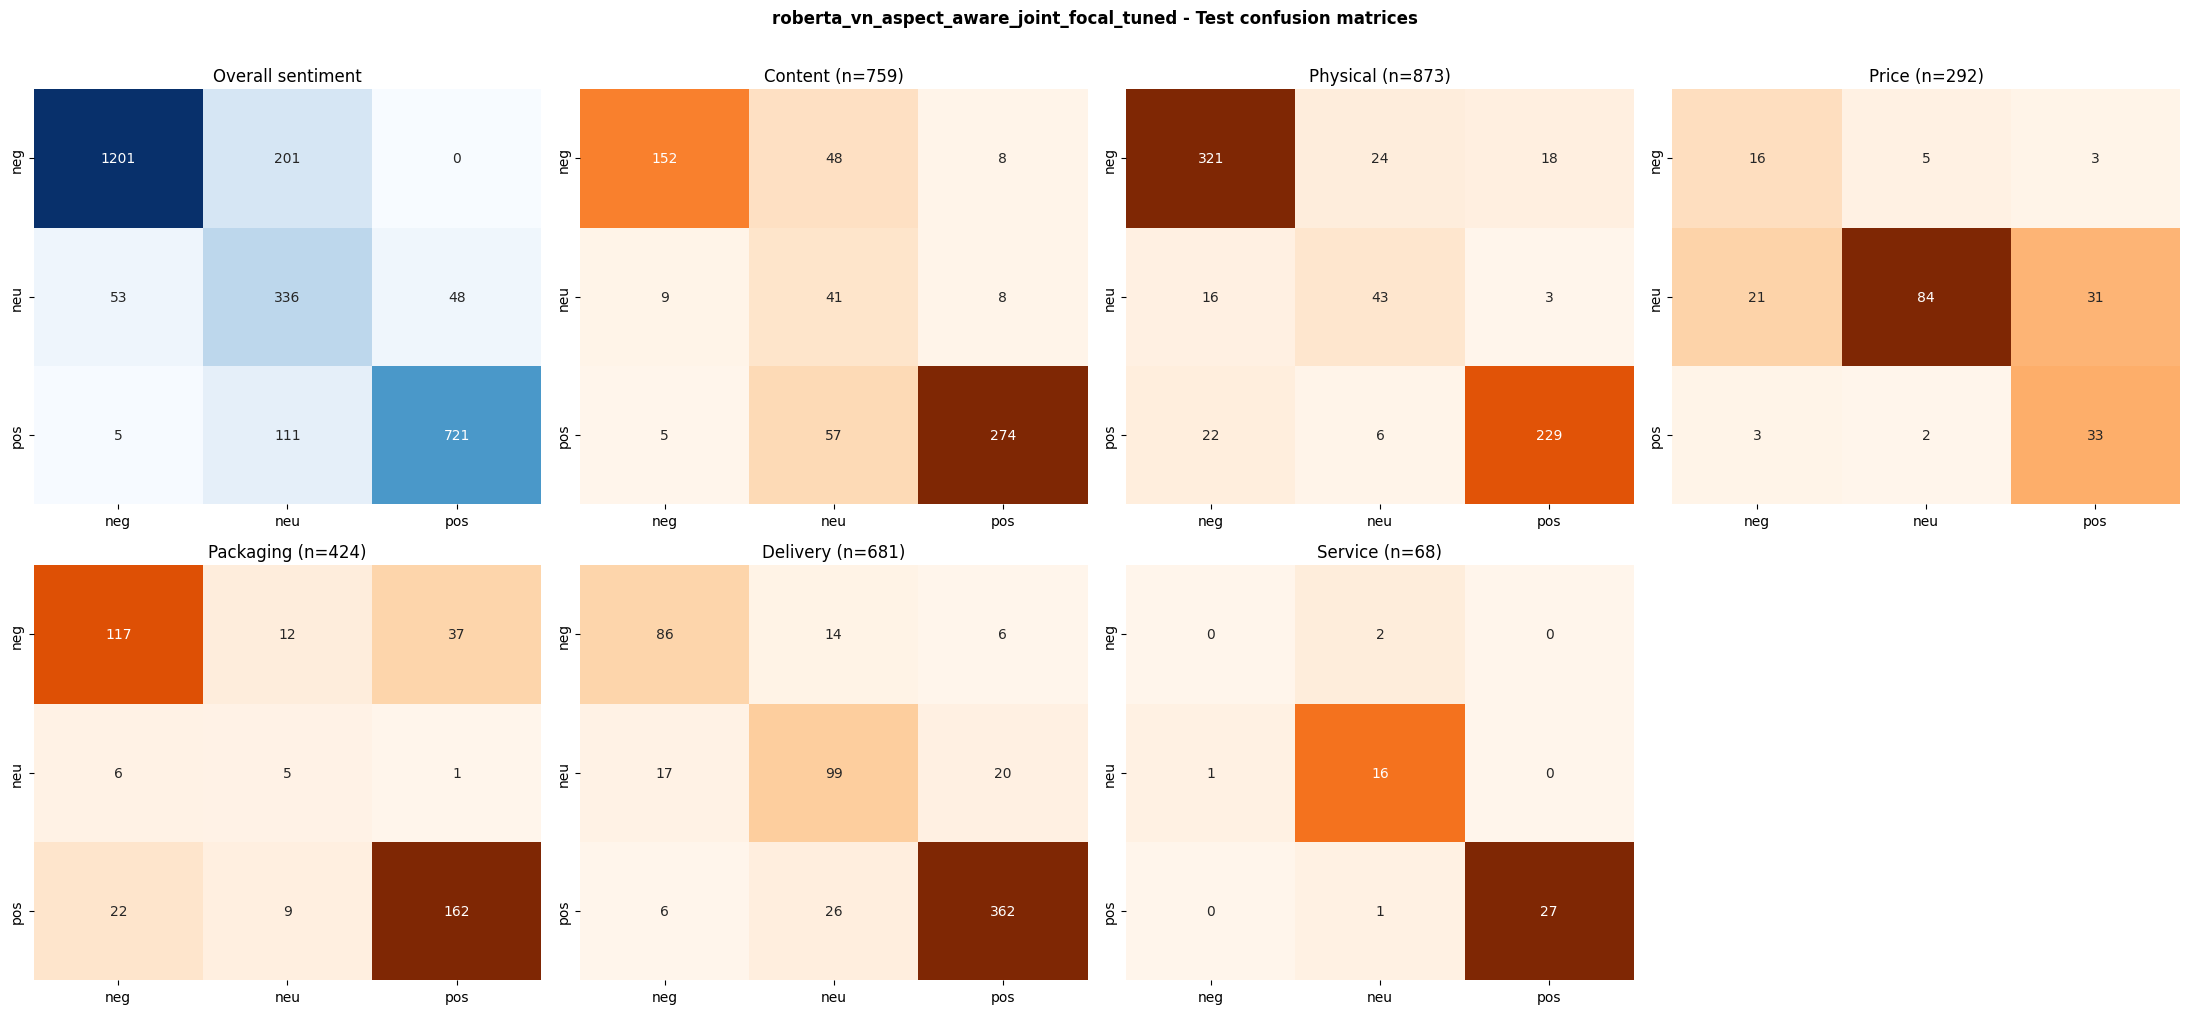

In [21]:
def plot_confusion_matrices(true_sentiment: np.ndarray, pred_sentiment: np.ndarray, true_aspects: np.ndarray, pred_aspects: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    sent_cm = confusion_matrix(true_sentiment, pred_sentiment, labels=SENTIMENT_CLASSES)
    sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=axes[0])
    axes[0].set_title('Overall sentiment')

    for idx, col in enumerate(ASPECT_COLS):
        ax = axes[idx + 1]
        mask = true_aspects[:, idx] != ABSENT_CLASS
        if mask.sum() == 0:
            ax.set_visible(False)
            continue
        cm = confusion_matrix(true_aspects[:, idx][mask], pred_aspects[:, idx][mask], labels=SENTIMENT_CLASSES)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=ax)
        ax.set_title(f'{ASPECT_DISPLAY[col]} (n={mask.sum()})')

    if len(axes) > 7:
        axes[7].set_visible(False)
    plt.suptitle(f'{EXPERIMENT_NAME} - Test confusion matrices', y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

raw_pred = trainer.predict(test_dataset)
pred_sentiment, pred_aspect, _ = decode_predictions(raw_pred.predictions, thresholds=best_thresholds)
true_sentiment = raw_pred.label_ids[:, 0]
true_aspects = raw_pred.label_ids[:, 1:]

print('=== SENTIMENT (TEST) ===')
print(classification_report(true_sentiment, pred_sentiment, labels=SENTIMENT_CLASSES, target_names=['neg', 'neu', 'pos'], zero_division=0))
print('=== ASPECTS (present only, TEST) ===')
present_mask = true_aspects.flatten() != ABSENT_CLASS
print(classification_report(true_aspects.flatten()[present_mask], pred_aspect.flatten()[present_mask], labels=SENTIMENT_CLASSES, target_names=['neg', 'neu', 'pos'], zero_division=0))
plot_confusion_matrices(true_sentiment, pred_sentiment, true_aspects, pred_aspect)


## 13. Demo inference
Th? m? h?nh tr?n v?i c?u review ng?n ?? xem d? ?o?n sentiment v? t?ng aspect.


Thử mô hình trên vài câu review ngắn để xem dự đoán sentiment và từng aspect.


In [22]:
def predict_review(title: str, body: str) -> dict:
    sample = pd.DataFrame([{'title': title, 'body': body}])
    dataset = ABSADataset(sample, tokenizer, with_labels=False)
    raw = trainer.predict(dataset)
    pred_sentiment, pred_aspect, pred_presence = decode_predictions(raw.predictions, thresholds=best_thresholds)

    sentiment_id = int(pred_sentiment[0])
    return {
        'sentiment_id': sentiment_id,
        'sentiment_label': {0: 'neg', 1: 'neu', 2: 'pos'}[sentiment_id],
        'aspects': {
            col: {'presence': int(pred_presence[0, idx]), 'label_id': int(pred_aspect[0, idx])}
            for idx, col in enumerate(ASPECT_COLS)
        },
    }


def print_prediction(result: dict):
    print(f"\nTITLE: {result['sentiment_label']}")
    for col, item in result['aspects'].items():
        print(f"{col}: presence={item['presence']} label_id={item['label_id']}")


DEMO_TEXTS = [
    ('Sach dep, in ro rang', 'Sach dep, noi dung hay, giao hang nhanh, dong goi can than.'),
    ('Bia bi rach', 'Sach bi quay goc, giao cham va ho tro khong tot.'),
    ('Gia hop ly', 'Gia vua phai, chat luong on, nhung giao hang con cham.'),
]
for title, body in DEMO_TEXTS:
    print_prediction(predict_review(title, body))



TITLE: pos
as_content: presence=0 label_id=3
as_physical: presence=1 label_id=2
as_price: presence=0 label_id=3
as_packaging: presence=0 label_id=3
as_delivery: presence=1 label_id=2
as_service: presence=0 label_id=3



TITLE: neu
as_content: presence=0 label_id=3
as_physical: presence=0 label_id=3
as_price: presence=0 label_id=3
as_packaging: presence=0 label_id=3
as_delivery: presence=0 label_id=3
as_service: presence=0 label_id=3



TITLE: neu
as_content: presence=0 label_id=3
as_physical: presence=0 label_id=3
as_price: presence=0 label_id=3
as_packaging: presence=0 label_id=3
as_delivery: presence=0 label_id=3
as_service: presence=0 label_id=3
